# 01-07 - Buffers, Within and Intersects

A buffer is the simplest spatial question there is: everything within a given distance of something. In 01-04 we used one without ever looking at it.

Here we look at it. We see what shape `buffer` actually returns, why a circle drawn by a computer is a polygon with a countable number of corners, and then we meet the distinction that decides more analyses than any other in this course: a building that lies entirely inside your circle, and a building that merely touches it.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

In [2]:
buildings = gpd.read_file("data/princeton_buildings.geojson").to_crs("EPSG:26918")
food = gpd.read_file("data/princeton_food.geojson").to_crs("EPSG:26918")

landmarks = pd.read_csv("data/landmarks.csv")
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:26918")

dinky = places[places["id"] == "dinky"].geometry.iloc[0]
print(f"{len(buildings)} buildings, {len(food)} places to eat, all in metres")

7893 buildings, 92 places to eat, all in metres


Note that we reprojected everything to `EPSG:26918` in the same cell we loaded it. From here on every number is in metres, and we never have to think about it again. That is a good habit: convert once, at the top, rather than sprinkling `to_crs` through your analysis.

## What a buffer actually is

`buffer` takes a distance and returns a new shape containing everything within that distance of the original:

In [3]:
circle = dinky.buffer(400)

print(type(circle))
print(f"corners: {len(circle.exterior.coords)}")
print(f"area:    {circle.area / 1e6:.3f} square kilometres")

<class 'shapely.geometry.polygon.Polygon'>
corners: 65
area:    0.502 square kilometres


Three things worth reading there.

It is a **Polygon**, not a circle. Computers do not draw true circles, they approximate them with straight edges, and this one has 65 corners.

Its **area is 0.502 square kilometres**, and a true circle of radius 400 metres would be 0.503. The approximation costs about a fifth of a percent, which is far smaller than any uncertainty in the underlying data and entirely fine.

You can ask for a finer approximation with the `resolution` argument if you ever need one, at the cost of a shape with more points in it. For counting things, the default is more than enough.

## The question that has two answers

Now the distinction. We want the buildings near the Dinky station, and there are two entirely reasonable meanings of "near".

**`within`** asks whether a building lies *entirely inside* the circle. **`intersects`** asks whether it touches the circle *at all*, including buildings that straddle the edge.

In [4]:
entirely_inside = buildings.within(circle)
touching_at_all = buildings.intersects(circle)

print(f"within:     {entirely_inside.sum()}")
print(f"intersects: {touching_at_all.sum()}")
print(f"difference: {touching_at_all.sum() - entirely_inside.sum()} buildings straddle the edge")

within:     91
intersects: 105
difference: 14 buildings straddle the edge


91 and 105, differing by 14.

Neither number is wrong. They answer different questions, and which one you want depends on what you are going to do with it. If you are asking how many households are certainly within a short walk, `within` is conservative and defensible. If you are asking which properties would be affected by something, `intersects` is the one that does not miss anybody.

**What is not defensible is a report that says "105 buildings within 400 metres" without saying which predicate it used**, because nobody can reproduce it. This is a real and common failure in professional work, and it costs nothing to avoid.

## Seeing the fourteen

Counting tells us there are 14. Looking tells us what they are:

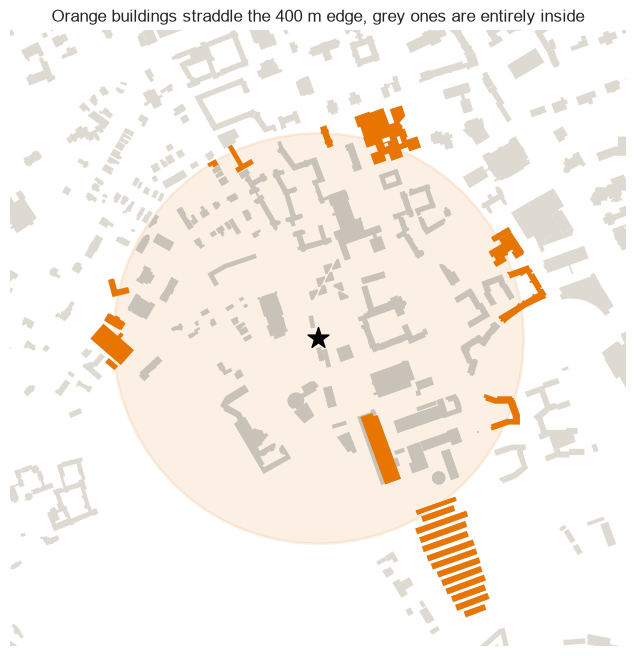

In [5]:
straddlers = buildings[touching_at_all & ~entirely_inside]

ax = gpd.GeoSeries([circle], crs="EPSG:26918").plot(
    figsize=(8, 8), color="#e77500", alpha=0.10, edgecolor="#e77500", linewidth=2)
buildings.plot(ax=ax, color="#dedad2", linewidth=0)
buildings[entirely_inside].plot(ax=ax, color="#c8c2b8", linewidth=0)
straddlers.plot(ax=ax, color="#e77500", linewidth=0)
gpd.GeoSeries([dinky], crs="EPSG:26918").plot(ax=ax, color="black", marker="*", markersize=250)

bounds = dinky.buffer(600).bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])
ax.set_title("Orange buildings straddle the 400 m edge, grey ones are entirely inside")
ax.set_axis_off()

The orange buildings sit on the boundary of the circle, and every one of them is a coin toss between the two answers.

Note that the two conditions were combined with `&` for "and" and `~` for "not", i.e. touching and not entirely inside. Those symbols are how you combine conditions on a table, and the brackets around each condition are required.

## Why the food count did not have this problem

In 01-04 we counted places to eat, not buildings, and we never had to think about this. Here is why:

In [6]:
e225 = places[places["id"] == "e225"].geometry.iloc[0]
food_circle = e225.buffer(400)

print(f"food within:     {food.within(food_circle).sum()}")
print(f"food intersects: {food.intersects(food_circle).sum()}")

food within:     20
food intersects: 20


Twenty and twenty, identical.

A point has no width. It cannot straddle anything, so it is either inside or it is not, and the two predicates agree by necessity.

That is worth stating as a rule, because it tells you when to care: **the distinction matters exactly when your geometry has size.** Points, never. Buildings, parcels, census tracts and flood zones, always.

## The other predicates

There are a few more, and they are easier to keep straight as a family than one at a time:

In [7]:
sample = buildings[touching_at_all].head(3)

comparison = pd.DataFrame({
    "within":     sample.within(circle),
    "intersects": sample.intersects(circle),
    "disjoint":   sample.disjoint(circle),
})
comparison

,within,intersects,disjoint
1025,True,True,False
1026,True,True,False
1027,True,True,False


`disjoint` is simply the opposite of `intersects`, i.e. they do not touch at all. Note that `within` and `disjoint` can never both be true, and `intersects` and `disjoint` are always opposites.

There is also `contains`, which is `within` the other way round: `circle.contains(building)` asks the same question as `building.within(circle)`. Which one you write is a matter of what you want to put first in the sentence.

## Check your understanding

1. Which predicate would you use to count parcels *affected* by a flood zone, and which to count parcels *entirely lost* to it?
2. For the places to eat, `within` and `intersects` gave the same answer. Name the property of the data that makes them agree.
3. A colleague reports "105 buildings within 400 m of the station". What single word is missing, and why does it matter?
4. The 400 metre buffer had 65 corners rather than being a true circle. Does that affect the count of 105, and how would you check?

## Where we are

You know what a buffer returns, why it is a polygon, and the difference between two questions that sound identical in English and give different answers in code.

The habit worth keeping: whenever you count things inside a shape, say which predicate you used. It is one word, and it is the difference between a number somebody can reproduce and a number they have to take on trust.

In 01-08 we go back to the map we drew in class and learn to read it honestly.

## Further resources

Nothing in this course requires anything below.

Shapely is the library underneath geopandas that computes all of this, and its manual illustrates each predicate with pictures: https://shapely.readthedocs.io/en/stable/manual.html#binary-predicates. The geopandas guide to the same operations, applied to whole tables, is at https://geopandas.org/en/stable/docs/user_guide/set_operations.html.

The buildings are an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright.